## Task 1
The MI5 intercepts an audio file (Ex3_sound1.wav). You are suspicious that it contains secret data
embedded in the file by the LSB audio steganography method, a common method of audio
steganography consisting of hiding the secret data into the least significant bit (LSB) of an audio file.

The first task of Exercise 3 is to create an application in Python (exercise 3.1) that must extract and read the hidden message embedded in Ex3_sound1.wav.

In [1]:
!pip install wave
!pip install numpy

  Preparing metadata (setup.py) ... done
  Created wheel for wave: filename=Wave-0.0.2-py3-none-any.whl size=1220 sha256=97f1b61a70df1cea1366bcead6859c82e17e8c52e6221bbb35b08458d470a544
  Stored in directory: /Users/zymawy/Library/Caches/pip/wheels/9c/ca/18/1b5c2e79061f666af1114a80567bbfdc72b1d9bcb5a584462c
Successfully built wave
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 573.5 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 10.2 MB/s eta 0:00:0000:0100:01


In [15]:
import wave
import itertools

def extract_hidden_message_from_audio(audio_file_path):
    # Open the audio file and read its frames
    with wave.open(audio_file_path, 'rb') as audio_file:
        frames = audio_file.readframes(audio_file.getnframes())
    
    frame_bytes = bytearray(frames)

    bits = (frame_byte & 1 for frame_byte in frame_bytes)
    
    chars = []
    for byte_bits in itertools.zip_longest(*[iter(bits)] * 8):
        byte = int(''.join(map(str, byte_bits)), 2)
        chars.append(chr(byte))
    
    hidden_message = ''.join(chars).split("###")[0]

    return hidden_message


In [16]:
message = extract_hidden_message_from_audio('Ex3_sounds/Ex3_sound1.wav')
print("Hidden Message Is :", message)

Hidden Message Is : Mom I will not be home for supper


## Task 2
The second task consists of analysing a group of suspicious audio files (Ex3_sound2.wav,
Ex3_sound3.wav and Ex3_sound4.wav), determining which one contains a four-number secret code.
In this case, the spy has used a more sophisticated method. It seems he has used amplitude
modulation to ‘move’ the secret code to an ultrasonic range of frequencies, then mixing this code
with that of the suspicious audio files.

To solve this task, you must create an application in Python (exercise 3.2) that should detect which
one of the audio files seems to contain suspicious data in an ultrasonic range of frequencies, and
should be able to play the secret code in an audible range of frequencies.

In [17]:
!pip install matplotlib
!pip install scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 1.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 9.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.1/262.1 kB 4.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 10.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 10.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 555.4 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 8.6 MB/s eta 0:00:0000:0100:01m


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile


def detect_ultrasonic(filename):
    rate, data = wavfile.read(filename)
    spectrum = np.fft.fft(data)
    freqs = np.fft.fftfreq(len(spectrum))

    plt.plot(freqs, np.abs(spectrum))
    plt.title('Frequency Spectrum')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.show()

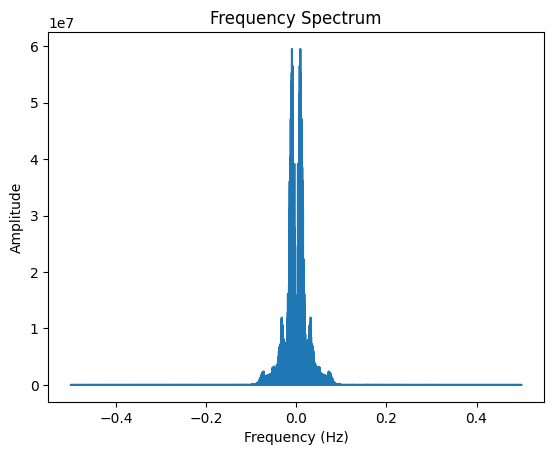

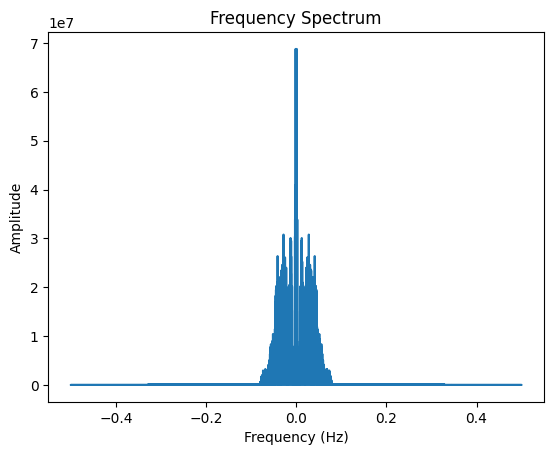

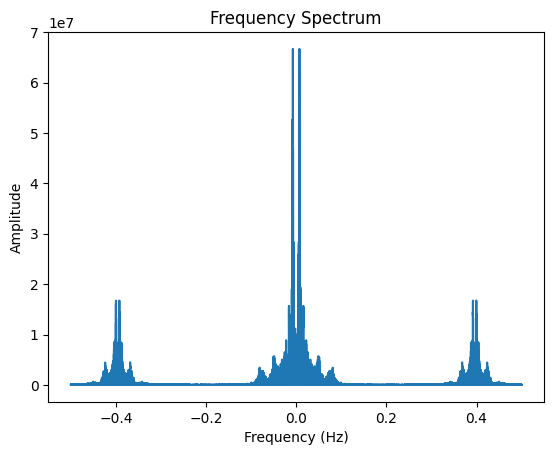

In [20]:
detect_ultrasonic('Ex3_sounds/Ex3_sound2.wav')
detect_ultrasonic('Ex3_sounds/Ex3_sound3.wav')
detect_ultrasonic('Ex3_sounds/Ex3_sound4.wav')

## Task 3
The third task consists of creating a more sophisticated algorithm for embedding hidden messages
based on the LSB audio steganography method (exercise 3.3). You will create an application in
Python and use the audio file Ex3_sound5.wav to embed the secret message ‘Father Christmas does
not exist’. The application must include an algorithm that performs the opposite operation (i.e. an
algorithm able to extract the hidden message embedded in Ex3_sound5.wav).

You could, for example, to distribute the hidden message through non-consecutive audio samples
using a random pattern, use more than one least significant bits to hide the secret data, etc.

In [39]:
import wave

def embed_lsb_enhanced(audio_filename, string, output_filename):
	# We will use wave package available in native Python installation to read and write .wav audio file
	import wave
	# read wave audio file
	audio = wave.open(audio_filename, mode='rb')
	# Read frames and convert to byte array
	frame_bytes = bytearray(list(audio.readframes(audio.getnframes())))

	# The "secret" text message
	# Append dummy data to fill out rest of the bytes. Receiver shall detect and remove these characters.
	string = string + int((len(frame_bytes) - (len(string) * 8 * 8)) / 8) * '#'
	# Convert text to bit array
	bits = list(map(int, ''.join(
		[bin(ord(i)).lstrip('0b').rjust(8, '0') for i in string])))

	# Replace LSB of each byte of the audio data by one bit from the text bit array
	for i, bit in enumerate(bits):
		frame_bytes[i] = (frame_bytes[i] & 254) | bit
	# Get the modified bytes
	frame_modified = bytes(frame_bytes)

	# Write bytes to a new wave audio file
	with wave.open(output_filename, 'wb') as fd:
		fd.setparams(audio.getparams())
		fd.writeframes(frame_modified)
	audio.close()


In [40]:
embed_lsb_enhanced('Ex3_sounds/Ex3_sound5.wav', 'Father Christmas does not exist', 'output.wav')

In [35]:
!pip install thinkx
!pip install librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.1/260.1 kB 1.5 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 5.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 10.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 11.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 414.4/414.4 kB 6.6 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.1/31.1 MB 11.0 MB/s eta 0:00:0000:0100:01


In [36]:
from IPython.display import Audio
import librosa as lr

system, sr = lr.load("output.wav", sr=44100)
audio_system = Audio(data=system, rate=sr)
audio_system

In [41]:
def extract_lsb_enhanced(file):
	audio = wave.open(file, mode='rb')
	# Use wave package (native to Python) for reading the received audio file
	# import wave	# Convert audio to byte array
	frame_bytes = bytearray(list(audio.readframes(audio.getnframes())))

	# Extract the LSB of each byte
	extracted = [frame_bytes[i] & 1 for i in range(len(frame_bytes))]
	# Convert byte array back to string
	string = "".join(chr(int("".join(map(str, extracted[i:i + 8])), 2)) for i in
					 range(0, len(extracted), 8))
	# Cut off at the filler characters
	decoded = string.split("###")[0]

	# Print the extracted text
	# print("Sucessfully decoded: " + decoded)
	audio.close()
	return decoded

In [42]:
hidden_message = extract_lsb_enhanced('output.wav')
print("Hidden message:", hidden_message)

Hidden message: Father Christmas does not exist
